In [1]:
import pandas as pd
df = pd.read_csv('../data/public_transport_delays.csv')
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [2]:
#shape and column
df.shape
df.columns
#basic stats
df.describe()
#checking for missing values
df.isnull().sum()

trip_id                          0
date                             0
time                             0
transport_type                   0
route_id                         0
origin_station                   0
destination_station              0
scheduled_departure              0
scheduled_arrival                0
actual_departure_delay_min       0
actual_arrival_delay_min         0
weather_condition                0
temperature_C                    0
humidity_percent                 0
wind_speed_kmh                   0
precipitation_mm                 0
event_type                    1173
event_attendance_est             0
traffic_congestion_index         0
holiday                          0
peak_hour                        0
weekday                          0
season                           0
delayed                          0
dtype: int64

In [3]:
df['event_type'] = df['event_type'].fillna('None')
# verify
df['event_type'].isnull().sum()

np.int64(0)

In [18]:
df['event_type'].value_counts()

event_type
None        1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

In [4]:
df.groupby('event_type')['actual_arrival_delay_min'].mean().sort_values(ascending=False)

event_type
Protest     13.895349
Parade      13.619048
None        13.526002
Concert     12.832512
Sports      12.820755
Festival    12.769231
Name: actual_arrival_delay_min, dtype: float64

In [5]:
df['delayed'].value_counts(normalize=True)

delayed
1    0.7495
0    0.2505
Name: proportion, dtype: float64

In [6]:
df[['actual_departure_delay_min', 'actual_arrival_delay_min']].describe()

,actual_departure_delay_min,actual_arrival_delay_min
count,2000.000000,2000.000000
mean,8.688000,13.318000
std,6.268118,9.289727
min,-2.000000,-3.000000
25%,3.000000,5.000000
50%,9.000000,13.000000
75%,14.000000,21.000000
max,19.000000,29.000000


In [7]:
df['transport_type'].value_counts()

transport_type
Bus      525
Train    493
Tram     491
Metro    491
Name: count, dtype: int64

In [8]:
df[['actual_arrival_delay_min', 'temperature_C', 'humidity_percent', 
    'wind_speed_kmh', 'precipitation_mm', 'traffic_congestion_index']].corr()

,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,traffic_congestion_index
actual_arrival_delay_min,1.000000,-0.039944,-0.027705,-0.007649,0.001106,-0.011006
temperature_C,-0.039944,1.000000,-0.009675,-0.030514,-0.002967,0.023690
humidity_percent,-0.027705,-0.009675,1.000000,-0.002398,-0.036747,0.002751
wind_speed_kmh,-0.007649,-0.030514,-0.002398,1.000000,0.001786,0.009902
precipitation_mm,0.001106,-0.002967,-0.036747,0.001786,1.000000,-0.002785
traffic_congestion_index,-0.011006,0.023690,0.002751,0.009902,-0.002785,1.000000


In [9]:
df['season'].value_counts()
df['weekday'].value_counts()

weekday
0    288
1    288
2    288
3    288
4    288
5    288
6    272
Name: count, dtype: int64

<Figure size 1000x500 with 0 Axes>

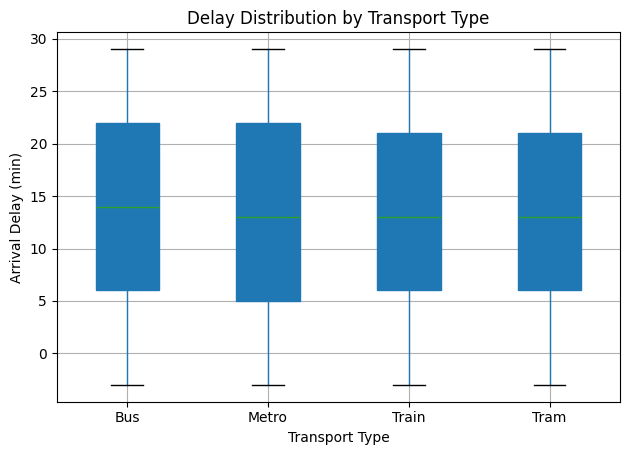

In [12]:
plt.figure(figsize=(10,5))
df.boxplot(column='actual_arrival_delay_min', by='transport_type', 
           patch_artist=True)
plt.title('Delay Distribution by Transport Type')
plt.suptitle('')
plt.xlabel('Transport Type')
plt.ylabel('Arrival Delay (min)')
plt.tight_layout()
plt.savefig('../outputs/boxplot_transport.png', dpi=150)
plt.show()

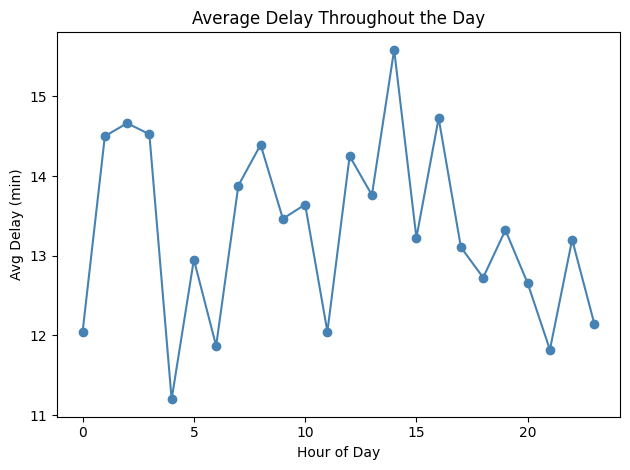

In [29]:
import matplotlib.pyplot as plt

df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour
df.groupby('hour')['actual_arrival_delay_min'].mean().plot(kind='line', marker='o', color='steelblue')
plt.title('Average Delay Throughout the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Delay (min)')
plt.tight_layout()
plt.savefig('../outputs/delay_by_hour.png', dpi=150)
plt.show()

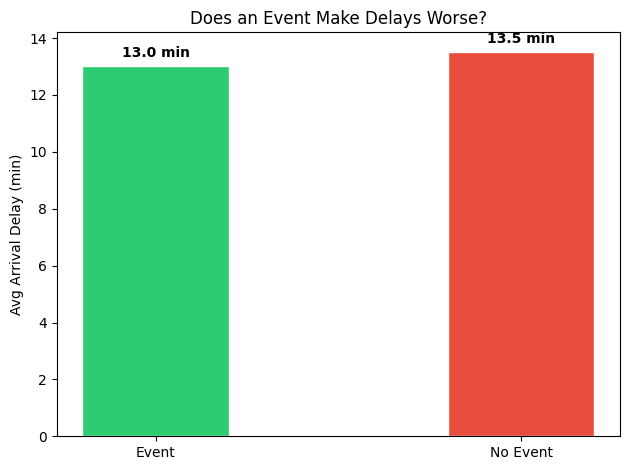

In [26]:
df['has_event'] = df['event_type'].apply(lambda x: 'No Event' if x == 'None' else 'Event')

values = df.groupby('has_event')['actual_arrival_delay_min'].mean()

colors = ['#2ecc71', '#e74c3c']  # green = no event, red = event
bars = plt.bar(values.index, values.values, color=colors, edgecolor='white', width=0.4)

# Add value labels on top of each bar
for bar, val in zip(bars, values.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{val:.1f} min', ha='center', va='bottom', fontweight='bold')

plt.title('Does an Event Make Delays Worse?')
plt.ylabel('Avg Arrival Delay (min)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/event_vs_no_event.png', dpi=150)
plt.show()

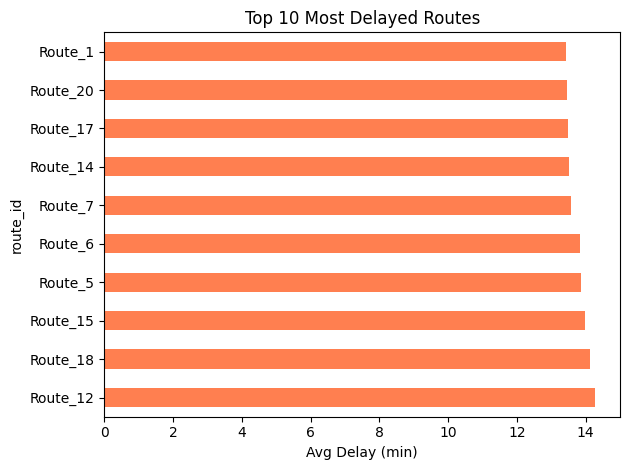

In [24]:
df.groupby('route_id')['actual_arrival_delay_min'].mean().sort_values(ascending=False).head(10).plot(kind='barh', color='coral')
plt.title('Top 10 Most Delayed Routes')
plt.xlabel('Avg Delay (min)')
plt.tight_layout()
plt.savefig('../outputs/top_delayed_routes.png', dpi=150)
plt.show()

<Figure size 1200x600 with 0 Axes>

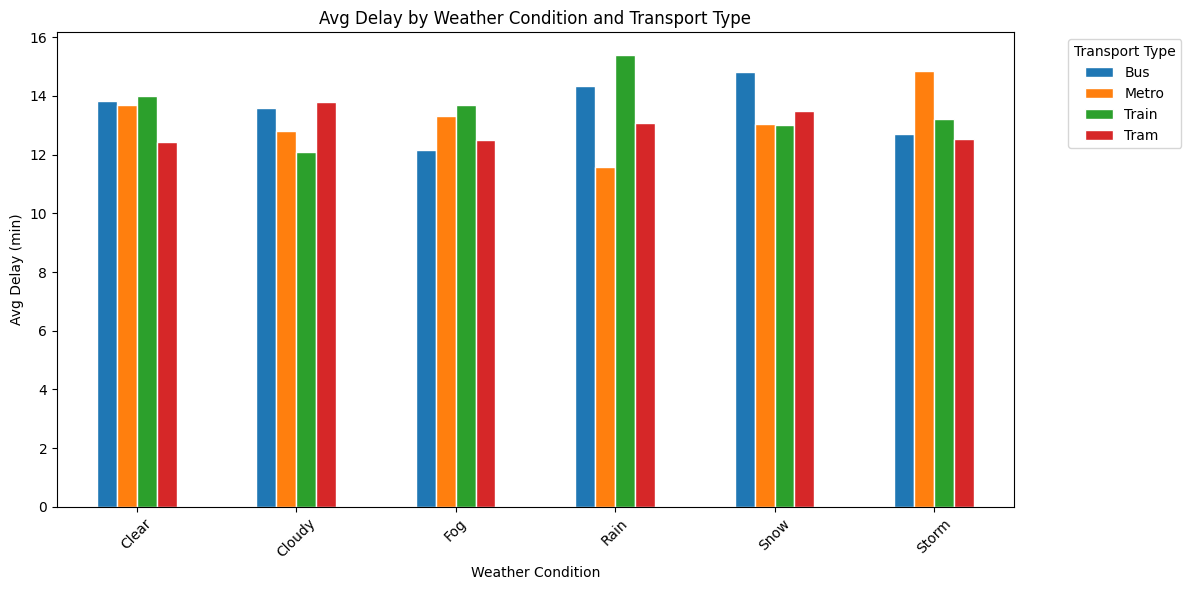

In [28]:
import seaborn as sns

plt.figure(figsize=(12, 6))
weather_transport = df.groupby(['weather_condition', 'transport_type'])['actual_arrival_delay_min'].mean().unstack()

weather_transport.plot(kind='bar', edgecolor='white', figsize=(12,6))
plt.title('Avg Delay by Weather Condition and Transport Type')
plt.xlabel('Weather Condition')
plt.ylabel('Avg Delay (min)')
plt.xticks(rotation=45)
plt.legend(title='Transport Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../outputs/weather_transport_grouped.png', dpi=150)
plt.show()